In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [6]:
torch.manual_seed(42)
#Fade data - 100 ads, 3 rows each (age, budget, platform)
x = torch.randn(100,3)

#Output - engagement score ( Formula = age*2 + budget*2 + platform*1)
eng_score = (x[:, 0]*2 + x[:, 1]*2 + x[:,2]*1).unsqueeze(1)

In [10]:
#network
class AdEngagementScore(nn.Module):
  def __init__(self):
    super().__init__()
    self.network = nn.Sequential(
        nn.Linear(3, 8),
        nn.ReLU(),
        nn.Linear(8, 4),
        nn.ReLU(),
        nn.Linear(4, 1)
    )

  def forward(self, x):
    return self.network(x)

model = AdEngagementScore()
print(model)


AdEngagementScore(
  (network): Sequential(
    (0): Linear(in_features=3, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=4, bias=True)
    (3): ReLU()
    (4): Linear(in_features=4, out_features=1, bias=True)
  )
)


In [12]:
#Loss function with optimization
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01) #assuming learning rate = 0.01

In [13]:
checks = 200 #number of checks through the loops
losses = [] #record losses

for check in range(checks):
  predictions = model(x) #forward to generate predictions

  loss = loss_fn(predictions, eng_score) #compute loss

  optimizer.zero_grad() #always gradient = 0, because pytorch automatically accumulates gradience, if we dont do this, its adding to the last of checks

  loss.backward() #backward pass

  optimizer.step() #updates weight

  losses.append(loss.item()) #Used to graph traning process later

  if check % 20 == 0:
    print(f"Check {check}, Loss: {loss.item():.4f}") #prints updates after 20 checks



Check 0, Loss: 10.8764
Check 20, Loss: 7.9707
Check 40, Loss: 4.0394
Check 60, Loss: 3.1865
Check 80, Loss: 2.7689
Check 100, Loss: 2.4414
Check 120, Loss: 2.1680
Check 140, Loss: 1.9295
Check 160, Loss: 0.7658
Check 180, Loss: 0.1309


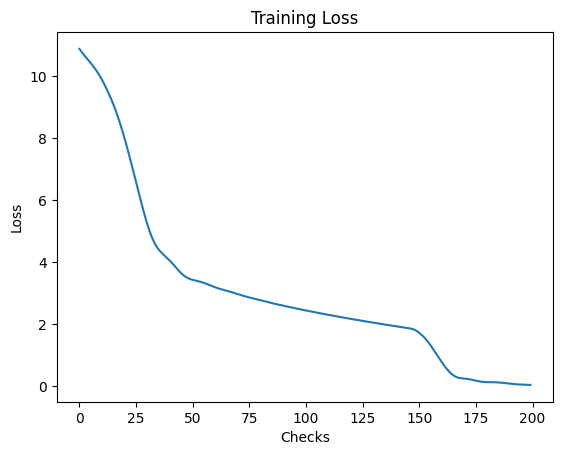

In [14]:
#Plot the loss
plt.plot(losses)
plt.xlabel("Checks")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()